In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from cellina import CellinaModel
from utils import set_seed
from train_loo import preprocess_adata

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

In [ ]:
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 50


In [5]:
import cellina
cellina.__version__

'0.7.1'

# Get dataset

In [6]:
set_seed(0)

In [7]:
slide_id = 'crc_210'

In [8]:
data_path = f"/data/a330d/datasets/crc/raw_zenodo/{slide_id}.h5ad"
adata = sc.read(data_path)
adata.obs_names_make_unique()

In [9]:
adata = preprocess_adata(adata, n_neighbors=200)

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [10]:
adata

AnnData object with n_obs × n_vars = 552241 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [11]:
labels_key = 'coarse_type'
domains_key = 'typ_clean'
batch_key = 'sid'

In [12]:
fig_save_path = "../figures/application"

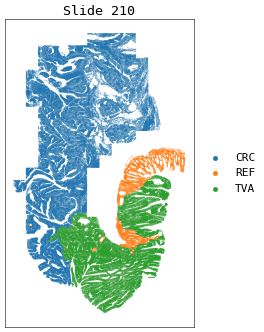

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))  # width x height in inches

sc.pl.spatial(
    adata,
    color=domains_key,
    ax=ax,
    spot_size=100,
    title=f"Slide 210",
    show=False,
)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}slide.png", bbox_inches='tight')

## Data splits

In [14]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_ct = "Fibroblast"
    is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
    is_holdout_ct = adata.obs[labels_key] == holdout_ct

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [15]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [16]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

# Train

In [17]:
model_base_path = f"data/cellina-reproducibility/application/{slide_id}"

In [18]:
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping

model_args = {
    'adata': adata,
    'n_latent': 64,
    'n_layers': 3,
    'use_observed_lib_size': True,
    'condition_on_intrinsic': False,
    'gene_likelihood': 'nb',
    'classifier_lambda': 1.,
    'discriminator_lambda': 1.,
    }
train_args = {'max_epochs': 100,
              'batch_size': 4096,
              'check_val_every_n_epoch': 1,
              'early_stopping': True,
              'devices': [0],
              'datasplitter_kwargs': {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              'enable_checkpointing':True,
              'callbacks': [
                  SaveCheckpoint(
                      monitor='vae_loss_validation',
                      dirpath=f"{model_base_path}",
                      load_best_on_end=True,
                      ),
                  EarlyStopping(
                      monitor="vae_loss_validation",
                      patience=5,
                      mode="min",
                    ),
                ],
    }

plan_kwargs = {
    'lr': 1e-3,
    'normalize_losses': True
    }

In [19]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [20]:
model = CellinaModel(
    **model_args, 
)
model.train(**train_args, plan_kwargs=plan_kwargs)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /data/ddimitrov/repos/cellina-reproducibility/notebooks/data/cellina-reproducibility/application/crc_210 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which 

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO     File                                                                                                      
         /data/ddimitrov/repos/cellina-reproducibility/notebooks/data/cellina-reproducibility/application/crc_210/e
         poch=26-step=5720-vae_loss_validation=309.9802551269531/model.pt already downloaded                       


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

# Inference and clustering

In [21]:
checkpoint_name = os.listdir(f"{model_base_path}")[0]
model = CellinaModel.load(
    f"{model_base_path}/{checkpoint_name}",
    adata=adata,
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File                                                                                                      
         data/cellina-reproducibility/application/crc_210/epoch=16-step=3520-vae_loss_validation=311.038330078125/m
         odel.pt already downloaded                                                                                


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [22]:
adata.obsm['cellina_basal'] = model.get_latent_representation(adata=adata, latent_key='z', batch_size=4096)
adata.obsm['cellina_spatial'] = model.get_latent_representation(adata=adata, latent_key='s', batch_size=4096)
# adata.obsm['cellina_latent'] = model.get_latent_representation(adata=adata, batch_size=4096)

### Latent visualization

In [23]:
x = 0.5  # fraction of cells to keep (e.g., 10%)

n_cells = adata.n_obs
n_subsample = int(n_cells * x)

# Randomly choose cell indices
np.random.seed(42)  # for reproducibility
subsample_idx = np.random.choice(n_cells, n_subsample, replace=False)

# Create the subsampled AnnData
adata_sub = adata[subsample_idx].copy()

In [24]:
sc.pp.neighbors(adata_sub, use_rep='cellina_basal')
sc.tl.umap(adata_sub)

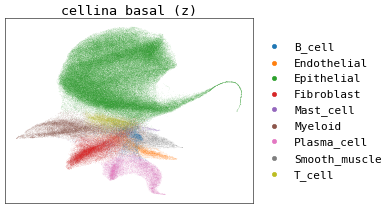

In [25]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/crc_210_umap_basal_ct.png", bbox_inches='tight')

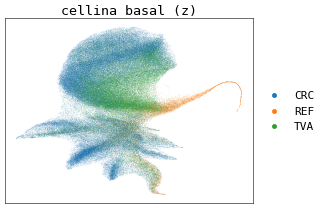

In [26]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_basal_niche.png", bbox_inches='tight')

In [27]:
sc.pp.neighbors(adata_sub, use_rep='cellina_spatial')
sc.tl.umap(adata_sub)

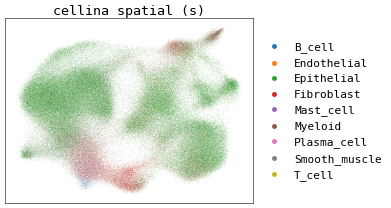

In [28]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, title="cellina spatial (s)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_ct.png", bbox_inches='tight')

In [29]:
palette = {
    # Control
    'REF': '#E69F00',

    # CRC
    'CRC': "#0075D5",

    # TVA
    'TVA': "#00B221",
}

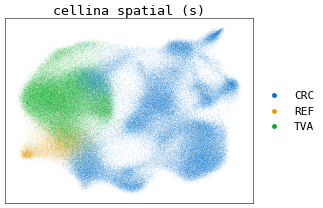

In [30]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, title="cellina spatial (s)", palette=palette)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_niche.png", bbox_inches='tight')

## Hotspot clusters

In [31]:
import pandas as pd
import decoupler as dc
import hotspot

from plotting import plot_custom_umap

In [32]:
adata_crc = adata[adata.obs[domains_key].str.contains('CRC')].copy()

In [33]:
hs = hotspot.Hotspot(
    adata_crc,
    layer_key="counts",
    model='danb',
    latent_obsm_key="cellina_spatial",
    umi_counts_obs_key="nCount_RNA"
)

hs.create_knn_graph(
    weighted_graph=False, n_neighbors=30,
)

In [34]:
hs_results = hs.compute_autocorrelations(jobs=24)

100%|██████████| 2000/2000 [00:08<00:00, 231.01it/s]


In [35]:
# Select the genes with significant lineage autocorrelation
top_k = 1200
hs_genes = hs_results.loc[hs_results.FDR < 0.05].head(top_k).index

In [36]:
# Compute pair-wise local correlations between these genes
load_lcz = False
base_dir = f'results/analysis/{slide_id}'
lcz_path = f'{base_dir}/hotspot_lcz_crc.csv'

if load_lcz:
    lcz = pd.read_csv(lcz_path, index_col=0)
    hs.local_correlation_z = lcz
else:
    lcz = hs.compute_local_correlations(hs_genes, jobs=24)
    os.makedirs(base_dir, exist_ok=True)
    lcz.to_csv(lcz_path)

Computing pair-wise local correlation on 1200 features...


100%|██████████| 719400/719400 [13:19<00:00, 899.41it/s]


In [37]:
modules = hs.create_modules(min_gene_threshold=100, core_only=True, fdr_threshold=0.05)

In [38]:
module_scores = hs.calculate_module_scores()

module_scores.head()

Computing scores for 4 modules...


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:47<00:00, 11.77s/it]


,1,2,3,4
c_1_1_1,-1.686645,0.534287,7.485766,-0.572624
c_1_1_2,-1.801062,1.447656,7.331687,-1.212035
c_1_1_3,-1.701486,2.023189,8.093203,-1.060070
c_1_1_4,-0.862436,4.077380,5.961052,-0.335745
c_1_1_5,-1.503948,1.351945,7.677480,-1.252290


In [39]:
module_cols = []
for c in module_scores.columns:
    key = f"Module {c}"
    adata_crc.obs[key] = module_scores[c]
    module_cols.append(key)

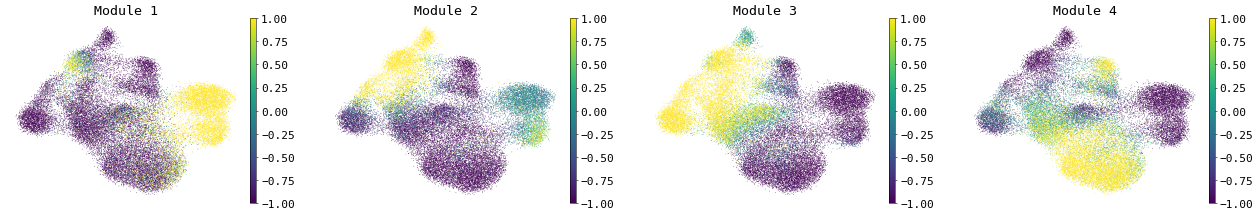

In [40]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=module_cols,frameon=False, vmin=-1, vmax=1, wspace=0.2
)

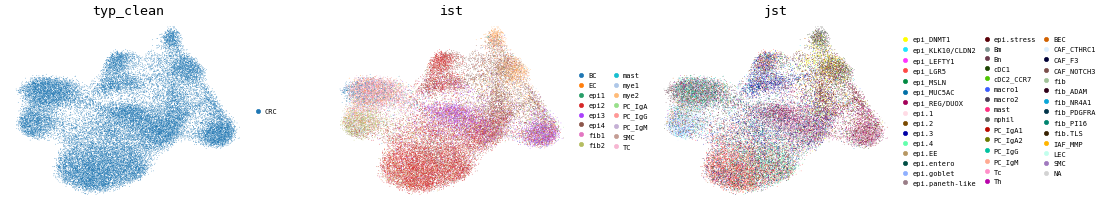

In [41]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=['typ_clean', 'ist', 'jst'], frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [42]:
module_scores_epi = module_scores.loc[adata_crc.obs_names]

In [43]:
adata_crc.obsm['module_scores'] = module_scores_epi.values

In [44]:
top_modules = module_scores.idxmax(axis=1)

# Add to adata.obs
adata_crc.obs["top_module"] = top_modules.astype(str)
adata_crc.obs["top_module"] = adata_crc.obs["top_module"].astype("category")

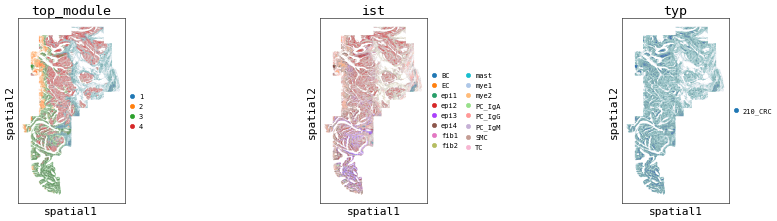

In [45]:
# Plot
sc.pl.spatial(
    adata_crc,
    color=["top_module", "ist", "typ"],
    palette=None,
    spot_size=50,
    show=True
)

In [46]:
# top module to f{CRC{}}
adata_crc.obs['microenvironment'] = adata_crc.obs['top_module'].apply(lambda x: f"CRC{x}")

In [47]:
adata_crc.obs['microenvironment'].value_counts()

microenvironment
CRC4    124781
CRC3     97862
CRC1     81291
CRC2     27454
Name: count, dtype: int64

### Remap

In [48]:
typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata_sub.obs_names)  # NaN for non-CRC cells

adata_sub.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata_sub.obs['typ'].astype(str))
)

typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata.obs_names)  # NaN for non-CRC cells
adata.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata.obs['typ'].astype(str))
)
    

In [49]:
adata.obs['microenvironment'].value_counts()

microenvironment
210_TVA    185092
CRC4       124781
CRC3        97862
CRC1        81291
210_REF     35761
CRC2        27454
Name: count, dtype: int64

/tmp/ipykernel_4006449/333694513.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')


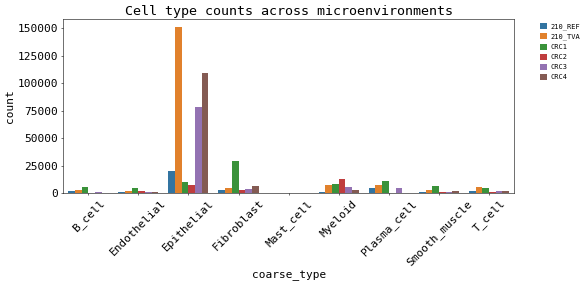

In [50]:
# Plot how many cells of each microenvironment are present in each cell type
celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=celltype_microenv_counts, x=labels_key, y='count', hue='microenvironment')
plt.xticks(rotation=45)
plt.title("Cell type counts across microenvironments")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Counterfactuals - CRC_global vs. CRC_microenv

In [51]:
celltypes = ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in m]
results = {k: adata[adata.obs[labels_key] == k] for k in celltypes}

In [52]:
print(microenvironments)

['CRC3', 'CRC2', 'CRC4', 'CRC1']


In [53]:
for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    is_celltype = adata.obs[labels_key].astype(str) == ct
    
    mask_control = ~is_tumor_region & is_celltype
    # mask_control = adata.obs[domains_key].astype(str).str.contains('REF', regex=True) & is_celltype # NOTE: changed from ~CRC to REF
    
    idx_control = np.where(mask_control.values)[0]

    # 1. Compute counterfactuals for global crc
    mask_target = is_tumor_region
    #mask_target = is_tumor_region & is_celltype
    idx_target = np.where(mask_target.values)[0]
    args = {
                "adata": adata,
                "indices": idx_control,
                "neighbour_indices": idx_target,
                "batch_size": 4096,
                "seed": 0,
            }
    results[ct].obsm['recon_x'] = model.get_normalized_expression(adata=results[ct], batch_size=4096, library_size=1e4)
    results[ct].uns[f'counterfactual_x_global'] = model.get_counterfactual_expression(**args, library_size=1e4)
    results[ct].uns[f'counterfactual_latents_global'] = model.get_counterfactual_latents(**args, latent_key='shifted')

    # 2. Loop over microenvironments
    for microenv in tqdm(microenvironments, desc=f"Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        mask_target = is_in_microenv
        #mask_target = is_in_microenv & is_celltype
        idx_target = np.where(mask_target.values)[0]
        args["neighbour_indices"] = idx_target
        results[ct].uns[f'counterfactual_x_{microenv}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{microenv}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

Cell types:   0%|          | 0/5 [00:00<?, ?it/s]

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


...

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
Cell types: 100%|██████████| 5/5 [01:01<00:00, 12.29s/it]


In [54]:
from scipy.stats import pearsonr, spearmanr
from counterfactual_analysis import safe_log2_fold_change

def _normalize_counts(counts, counts_per_k=1e4, eps=1e-8):
    return counts / (counts.sum(axis=1, keepdims=True) + eps) * counts_per_k


def compute_correlations(control, target, counterfactual, normalize_counts=True, deg=200):
    if normalize_counts:
        control = _normalize_counts(control)
        target = _normalize_counts(target)
        counterfactual = _normalize_counts(counterfactual)

    mean_control = np.nanmean(control, axis=0)
    mean_target = np.nanmean(target, axis=0)
    mean_cf = np.nanmean(counterfactual, axis=0)

    # compute log2 fold changes
    gt_vec = safe_log2_fold_change(mean_target, mean_control)
    cf_vec = safe_log2_fold_change(mean_cf, mean_control)

    deg_scores = np.abs(gt_vec)
    top_features = np.argsort(-deg_scores)[:deg]
    pear, _ = pearsonr(gt_vec[top_features], cf_vec[top_features])
    spear, _ = spearmanr(gt_vec[top_features], cf_vec[top_features])
    """
    # Plot scatterplot of gt vs cf log fold changes - highlight top features in a different color
    import matplotlib.pyplot as plt
    plt.scatter(gt_vec, cf_vec)
    plt.xlabel('Ground Truth Log2 Fold Change')
    plt.ylabel('Counterfactual Log2 Fold Change')
    plt.title('GT vs CF Log2 Fold Change')
    
    # highlight top features in a different color
    plt.scatter(gt_vec[top_features], cf_vec[top_features], color='red')
    plt.show()
    """
    return float(pear), float(spear)

In [55]:
summary = []
deg = 200

for ct, dataset in tqdm(results.items(), desc="Computing correlations"):
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    mask_control = ~dataset.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    # mask_control = dataset.obs[domains_key].astype(str).str.contains('REF', regex=True) # NOTE: change from ~CRC to REF?

    control = dataset.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    is_ct = dataset.obs[labels_key].astype(str) == ct
    #mask_target = is_tumor_region & is_ct
    mask_target = is_tumor_region
    target = adata.layers['counts'].todense()[mask_target]
    target = np.asarray(target)

    counterfactual = dataset.uns['counterfactual_x_global']
    pear_global, spear_global = compute_correlations(control, target, counterfactual, deg=deg)

    summary.append({
        "cell_type": ct,
        "label": "CRC_global",
        "pearson": np.round(pear_global, 4),
        "spearman": np.round(spear_global, 4)
    })

    for microenv in tqdm(microenvironments, desc="Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        
        #mask_target = is_in_microenv & is_ct
        mask_target = is_in_microenv
        target = adata.layers['counts'].todense()[mask_target]

        target = np.asarray(target)
        counterfactual = dataset.uns[f'counterfactual_x_{microenv}']
        pear_microenv, spear_microenv = compute_correlations(control, target, counterfactual, deg=deg)
        summary.append({
            "cell_type": ct,
            "label": microenv,
            "pearson": np.round(pear_microenv, 4),
            "spearman": np.round(spear_microenv, 4)
        })

Computing correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Computing correlations: 100%|██████████| 5/5 [02:07<00:00, 25.52s/it]


In [56]:
summary_df = pd.DataFrame(summary)

In [57]:
# Save df
summary_df.to_csv(f"../results/microenvironments_{slide_id}.csv", index=False)

# Dumbbell plots

In [58]:
# load df
summary_df = pd.read_csv(f"../results/microenvironments_{slide_id}.csv")

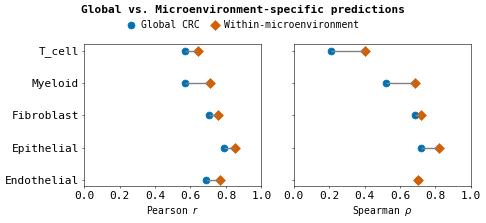

In [59]:
# Prepare data for plotting
plot_data = []
for corr_type in ["pearson","spearman"]:
    tmp = summary_df.copy()
    # Global value
    global_vals = tmp[tmp['label'] == 'CRC_global'].set_index('cell_type')[corr_type]
    # Mean of all others
    mean_others = tmp[tmp['label'] != 'CRC_global'].groupby('cell_type')[corr_type].mean()
    plot_data.append((global_vals, mean_others))

cell_types = summary_df['cell_type'].unique()

# Colorblind-friendly palette
colors = {
    'CRC_global': '#0072B2',      # blue
    'mean_others': '#D55E00'      # orange/red
}

# Monospace font
plt.rcParams['font.family'] = 'monospace'

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, (global_vals, mean_others), title in zip(
    axes, 
    plot_data, 
    [r"Pearson $r$", r"Spearman $\rho$"]
):
    y_pos = np.arange(len(cell_types))
    
    # Dumbbell lines
    ax.hlines(y=y_pos, xmin=mean_others.values, xmax=global_vals.values, color='gray', alpha=1, linewidth=2)
    
    # Scatter points with different shapes
    ax.scatter(global_vals.values, y_pos, color=colors['CRC_global'], s=100, marker='o', label='Global CRC')
    ax.scatter(mean_others.values, y_pos, color=colors['mean_others'], s=100, marker='D', label='Within-microenvironment')
    
    # Y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cell_types)
    #ax.set_xticklabels(ax.get_xticks(), fontsize=10)
    
    # X-axis
    ax.set_xlim(0, 1)
    ax.set_xlabel(title, fontsize=14)

# Overall figure title
fig.suptitle("Global vs. Microenvironment-specific predictions", fontsize=16, fontweight='bold', y=0.9)


# Get legend handles
handles, labels = axes[0].get_legend_handles_labels()

# Place legend BELOW the title, centered, horizontal
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.86),  # just below suptitle
    ncol=2,                      # horizontal layout
    frameon=False,
    fontsize=14,                  # increase text size
    markerscale=1.0
)
# Adjust subplots to make room for legend on far right
fig.subplots_adjust(top=0.88)  # shrink axes to leave 20% for legend

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(f"{fig_save_path}/dumbbell_{slide_id}.svg", bbox_inches='tight')
plt.show()

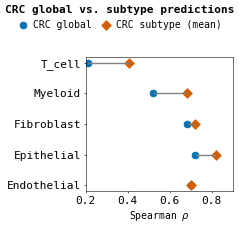

In [60]:
tmp = summary_df.copy()

global_vals = tmp[tmp['label'] == 'CRC_global'].set_index('cell_type')['spearman']
mean_others = tmp[tmp['label'] != 'CRC_global'].groupby('cell_type')['spearman'].mean()

cell_types = summary_df['cell_type'].unique()

# Colorblind-friendly palette
colors = {
    'CRC_global': '#0072B2',
    'mean_others': '#D55E00'
}

plt.rcParams['font.family'] = 'monospace'

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

y_pos = np.arange(len(cell_types))

# Dumbbell lines
ax.hlines(
    y=y_pos,
    xmin=mean_others.values,
    xmax=global_vals.values,
    color='gray',
    linewidth=2
)

# Points
ax.scatter(global_vals.values, y_pos,
           color=colors['CRC_global'], s=100, marker='o', label='CRC global')

ax.scatter(mean_others.values, y_pos,
           color=colors['mean_others'], s=100, marker='D', label='CRC subtype (mean)')

# Y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(cell_types)

# X-axis (UPDATED RANGE)
ax.set_xlim(0.2, 0.9)
ax.set_xlabel(r"Spearman $\rho$", fontsize=14)

# Title
fig.suptitle(
    "CRC global vs. subtype predictions",
    fontsize=16,
    fontweight='bold',
    y=0.92
)

# Legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.88),
    ncol=2,
    frameon=False,
    fontsize=14
)

# Layout
fig.subplots_adjust(top=0.82)
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig(f"{fig_save_path}/dumbbell_spearman_{slide_id}.svg", bbox_inches='tight')
plt.show()

In [61]:
# Read files in a loop, concatenate into a single dataframe, and plot distribution of pearson and spearman correlations across cell types for global vs microenv predictions
import glob

results_path = "../results"
all_files = glob.glob(f"{results_path}/microenvironments_*.csv")
dfs = []
for file in all_files:
    df = pd.read_csv(file)
    df['slide_id'] = file.split("_")[-1].split(".")[0]  # extract slide_id from filename
    dfs.append(df)
dumbbell_df = pd.concat(dfs, ignore_index=True)

In [62]:
tmp = dumbbell_df.copy()

# Create a new column grouping labels
tmp['group'] = np.where(
    tmp['label'] == 'CRC_global',
    'CRC global',
    'CRC subtype'
)

# Keep only needed columns
plot_df = tmp[['cell_type', 'group', 'spearman']]

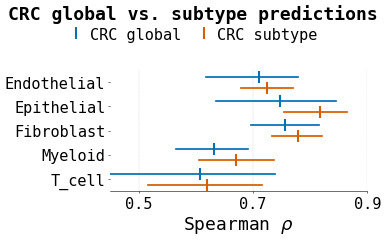

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

palette = {
    'CRC global': '#0072B2',
    'CRC subtype': '#D55E00'
}

# Just the mean + 95% CI — clean and tight
sns.pointplot(
    data=plot_df,
    x='spearman',
    y='cell_type',
    hue='group',
    palette=palette,
    dodge=0.45,
    markers='|',          # vertical line for the mean
    linestyles='none',
    errorbar=('ci', 95),
    err_kws={'linewidth': 2.5},
    markersize=16,        # make the line tall enough to read
    markeredgewidth=3.0,  # line thickness
    ax=ax
)

# Styling
ax.set_xlim(0.45, 0.9)
ax.set_xticks([0.5, 0.7, 0.9])
ax.set_xlabel(r"Spearman $\rho$", fontsize=26)
ax.set_ylabel("", fontsize=26)
ax.tick_params(axis='both', labelsize=22)
ax.xaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)

fig.suptitle(
    "CRC global vs. subtype predictions",
    fontsize=26,
    fontweight='bold',
    y=0.97
)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[:2], labels[:2],
    loc='upper center',
    bbox_to_anchor=(0.5, 0.91),
    ncol=2,
    frameon=False,
    fontsize=22,
    handletextpad=0.4,
    columnspacing=1.0
)
ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(f"{fig_save_path}/boxplot_spearman.svg", bbox_inches='tight', dpi=300)
plt.show()

In [64]:
def subsample_adata(adata, fraction=0.1, random_state=42):
    x = fraction

    n_cells = adata.n_obs
    n_subsample = int(n_cells * x)

    # Randomly choose cell indices
    np.random.seed(random_state)  # for reproducibility
    subsample_idx = np.random.choice(n_cells, n_subsample, replace=False)

    # Create the subsampled AnnData
    return adata[subsample_idx].copy()

In [65]:
adata.obsm['recon_x'] = model.get_normalized_expression(adata=adata, batch_size=4096, library_size=1e4)

In [66]:
# Get cellina spatial for non CRC cells
adata_list = []
select_ct = "Fibroblast"
adata_fib = results[select_ct].copy()
control_mask = adata_fib.obs[domains_key].astype(str).str.contains('REF')
X = adata_fib.obsm['recon_x'][control_mask.values, :]
X = np.log1p(X)
adata_control = ad.AnnData(X=X, 
                           obs=adata_fib.obs[control_mask])
#adata_list.append(subsample_adata(adata_control, fraction=0.1, random_state=0))
adata_list.append(subsample_adata(adata_control, fraction=1, random_state=0))

for microenv in microenvironments:
    # Get real latents for cells in this microenvironment
    real_mask = adata.obs['microenvironment'].astype(str).str.contains(microenv) & (adata.obs[labels_key].astype(str) == select_ct)
    X = adata.obsm['recon_x'][real_mask.values, :]
    X = np.log1p(X)
    obs=adata.obs[real_mask]
    adata_real = ad.AnnData(X=X, obs=obs)
    adata_real.obs['microenvironment'] = microenv
    #adata_list.append(subsample_adata(adata_real, fraction=0.2, random_state=0))
    adata_list.append(subsample_adata(adata_real, fraction=1., random_state=0))
    
    # Get counterfactual latents for this microenvironment
    X = adata_fib.uns[f'counterfactual_x_{microenv}']
    X = np.log1p(X)
    obs = adata_fib.obs[~adata_fib.obs[domains_key].str.contains('CRC')]
    obs['microenvironment'] = f"{microenv}_counterfactual"
    adata_cf = ad.AnnData(X=X, obs=obs)
    #adata_list.append(subsample_adata(adata_cf, fraction=0.1, random_state=0))
    adata_list.append(subsample_adata(adata_cf, fraction=1., random_state=0))

/tmp/ipykernel_4006449/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['microenvironment'] = f"{microenv}_counterfactual"
/tmp/ipykernel_4006449/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['microenvironment'] = f"{microenv}_counterfactual"
/tmp/ipykernel_4006449/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [67]:
# Merge all adatas in list
adata_fib_merged = ad.concat(adata_list, join='outer')
adata_fib_merged.obs_names_make_unique()

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [68]:
sc.pp.pca(adata_fib_merged, n_comps=50)
sc.pp.neighbors(adata_fib_merged, n_pcs=20)
sc.tl.umap(adata_fib_merged)

In [69]:
# rename REF, TVA to control
#adata_fib_merged.obs['microenvironment'] = adata_fib_merged.obs['microenvironment'].replace({'REF': 'Control', 'TVA': 'Control'})
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['microenvironment']
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['domain'].replace({'210_REF': 'Control'})
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['domain'].astype('category')

In [70]:
palette = {
    'CRC1': "#580803",
    'CRC1 CF': '#F4A582',  # lighter version
    'CRC2': "#011080",
    'CRC2 CF': '#92C5DE',  # lighter version
}

In [71]:
adata_fib_merged.obs['domain'].value_counts()

domain
CRC1                   28955
CRC1_counterfactual     7006
CRC2_counterfactual     7006
CRC4_counterfactual     7006
CRC3_counterfactual     7006
CRC4                    6272
CRC3                    3566
CRC2                    2736
Control                 2456
Name: count, dtype: int64

/tmp/ipykernel_4006449/1030890215.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sub.obs['domain_short'] = adata_sub.obs['domain'].replace({
... storing 'cell_id' as categorical
... storing 'cell' as categorical
... storing 'microenvironment' as categorical


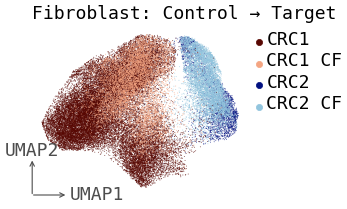

../figures/application/crc_210_umap_cf_Fibroblasts.svg


In [72]:
import matplotlib.pyplot as plt
import scanpy as sc

domains = ['CRC1', 'CRC1_counterfactual', 'CRC2', 'CRC2_counterfactual'] # 'Control',
adata_sub = adata_fib_merged[adata_fib_merged.obs['domain'].isin(domains)].copy()

adata_sub.obs['domain_short'] = adata_sub.obs['domain'].replace({
    'Control': 'Control',
    'CRC1': 'CRC1',
    'CRC1_counterfactual': 'CRC1 CF',
    'CRC2': 'CRC2',
    'CRC2_counterfactual': 'CRC2 CF'
})

ax = sc.pl.umap(
    adata_sub,
    color='domain_short',
    palette=palette,
    show=False,
    title='',
    size=8,
    alpha=0.7,
    frameon=False,
)

fig = ax.figure
fig.set_size_inches(6, 4)
ax.set_position([0.05, 0.08, 0.72, 0.84])

ax.set_title(
    f"{select_ct}: Control → Target",
    fontsize=26,
    # fontweight='bold',
    pad=12,
    loc='left',
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

arrow_kw = dict(arrowstyle='->', color='0.3', lw=1.6)
x0, y0 = ax.get_xlim()[0], ax.get_ylim()[0]
offset = (ax.get_xlim()[1] - x0) * 0.08
ax.annotate('', xy=(x0 + offset * 2, y0), xytext=(x0, y0),
            arrowprops=arrow_kw, annotation_clip=False)
ax.annotate('', xy=(x0, y0 + offset * 2), xytext=(x0, y0),
            arrowprops=arrow_kw, annotation_clip=False)
ax.text(x0 + offset * 2.2, y0, 'UMAP1', fontsize=26, color='0.3', va='center')
ax.text(x0, y0 + offset * 2.2, 'UMAP2', fontsize=26, color='0.3', ha='center')

legend = ax.get_legend()
if legend is not None:
    legend.set_title('')
    legend.get_frame().set_linewidth(0)
    legend.get_frame().set_alpha(0)
    for text in legend.get_texts():
        text.set_fontsize(26)
    for handle in legend.legend_handles:
        handle.set_sizes([80])
    legend.set_bbox_to_anchor((1.02, 1))
    legend.set_loc('upper left')

for coll in ax.collections:
    coll.set_rasterized(True)

plt.show()

fig.savefig(
    f"{fig_save_path}/{slide_id}_umap_cf_Fibroblasts.svg",
    dpi=300,
    bbox_inches='tight',
    transparent=True,
)
print(f"{fig_save_path}/{slide_id}_umap_cf_Fibroblasts.svg")

In [74]:
f"{select_ct}: Control → Target"

'Fibroblast: Control → Target'

### Pathways

In [75]:
from plotting import plot_pathway_activity

In [76]:
module_scores

,1,2,3,4
c_1_1_1,-1.686645,0.534287,7.485766,-0.572624
c_1_1_2,-1.801062,1.447656,7.331687,-1.212035
c_1_1_3,-1.701486,2.023189,8.093203,-1.060070
c_1_1_4,-0.862436,4.077380,5.961052,-0.335745
c_1_1_5,-1.503948,1.351945,7.677480,-1.252290
...,...,...,...,...
c_1_212_3205,-0.299614,5.118252,2.235724,-0.825808
c_1_212_3206,-0.802339,3.114134,3.148254,-1.421089
c_1_212_3208,-0.397254,7.165707,2.212597,-1.516437
c_1_212_3216,0.434626,4.099695,2.404768,-1.477881


In [77]:
# Get module x gene matrix
gene_modules = hs.modules
gene_c = hs.results[['C']]
df = gene_c.join(gene_modules.rename("Module"))
df = df[~(df["Module"].isna()) & (df["Module"] != -1.0)] # NOTE: drop NaNs and -1 (unassigned genes)
module_gene_matrix = df.pivot_table(index="Module", columns=df.index, values="C", fill_value=0)

In [78]:
hs.modules

CXCL8        2
COL1A1       1
IGHG1        1
HCAR3        2
MMP2         1
            ..
OR2M3       -1
CD2         -1
TGFB2       -1
CLEC7A      -1
TNFRSF11B    3
Name: Module, Length: 1200, dtype: int64

In [79]:
hs.results[['C']]

,C
Gene,
CXCL8,0.234713
COL1A1,0.279995
IGHG1,0.175203
HCAR3,0.129093
MMP2,0.174814
...,...
PRSS55,-0.000288
TRIM48,-0.000293
HAPSTR2,-0.000331


In [80]:
df['Module'].unique()

array([2., 1., 3., 4.])

In [81]:
module_gene_matrix

Gene,A2M,ABCA1,ABCB1,ABHD2,ACP5,ACTA2,ACTG2,ADAM19,ADAM28,ADAM33,...,WIPF1,WNT11,XDH,ZBTB16,ZC3H12A,ZCCHC24,ZEB2,ZFAND2A,ZFP36,ZNG1B
Module,,,,,,,,,,,,,,,,,,,,,
1.0,0.048076,0.005529,0.000000,0.000000,0.012204,0.039309,0.018399,0.010885,0.006601,0.006644,...,0.011215,0.000000,0.000000,0.008978,0.000000,0.008592,0.01257,0.000000,0.000000,0.009076
2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.075867,0.000000
3.0,0.000000,0.000000,0.000000,0.021399,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.024148,0.000000,0.026508,0.000000,0.00000,0.011907,0.000000,0.000000
4.0,0.000000,0.000000,0.018755,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.025834,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


In [82]:
pw_progeny = dc.op.progeny(organism="human")
pw_hallmark = dc.op.hallmark(organism="human")

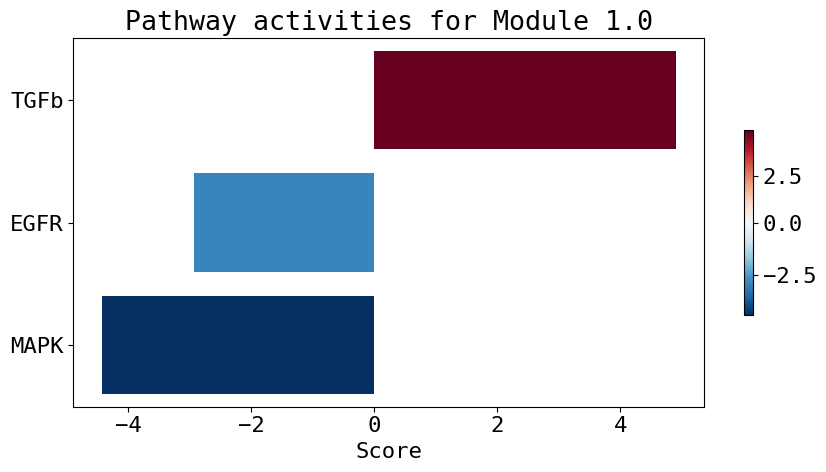

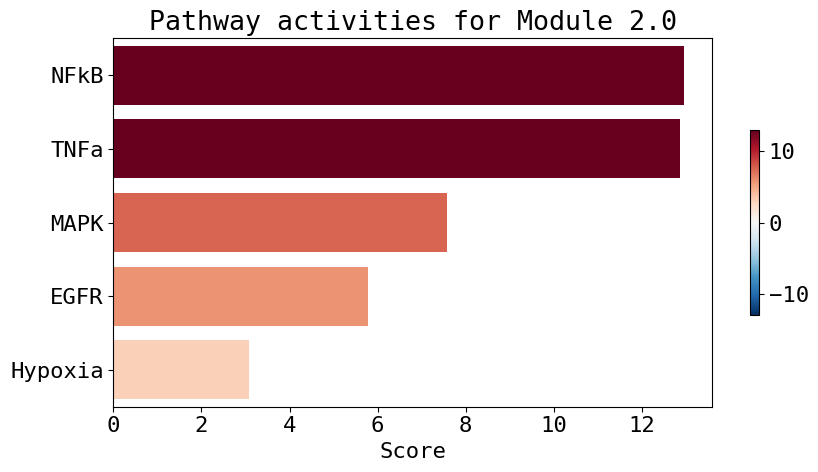

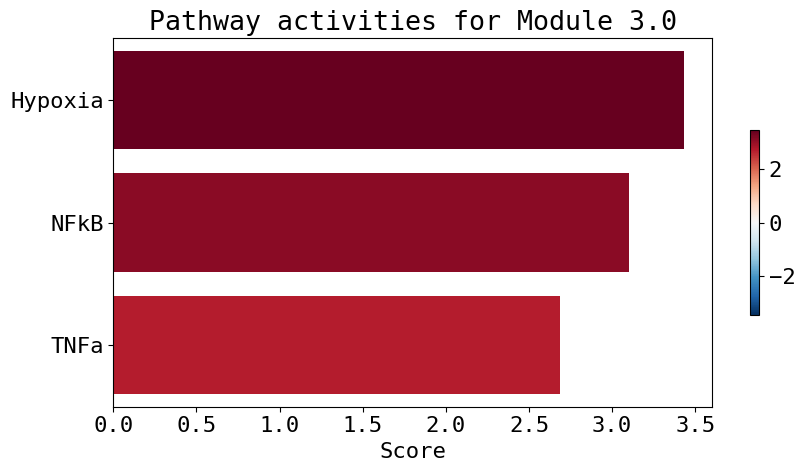

In [83]:
# Progeny pathway activity
pw_acts_progeny, pw_padj_progeny = dc.mt.ulm(data=module_gene_matrix, net=pw_progeny)
plot_pathway_activity(pw_acts_progeny, pw_padj_progeny, alpha=0.05)

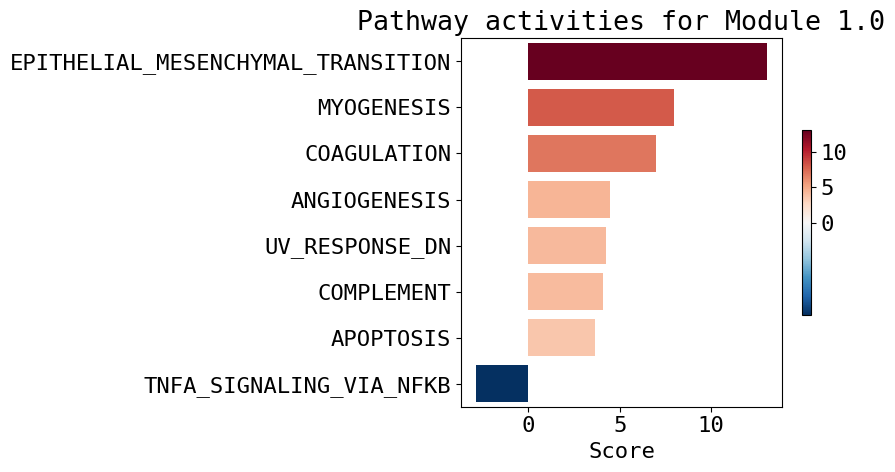

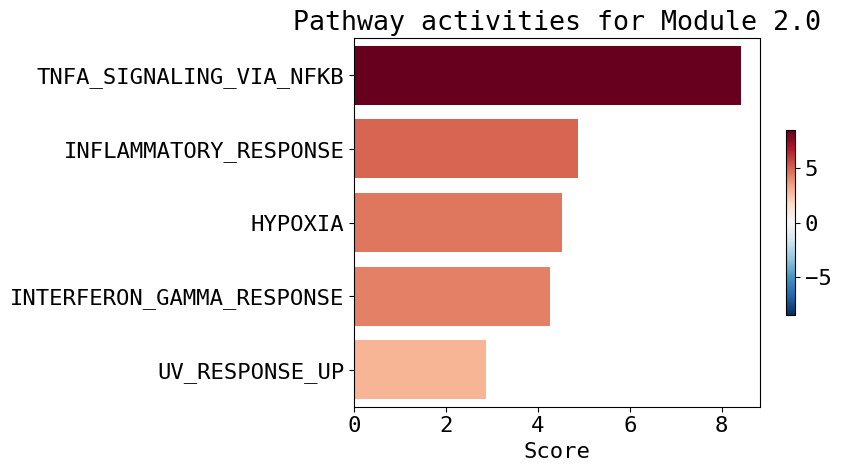

In [84]:
# Hallmark pathway activity
pw_acts_hallmark, pw_padj_hallmark = dc.mt.ulm(data=module_gene_matrix, net=pw_hallmark)
plot_pathway_activity(pw_acts_hallmark, pw_padj_hallmark, alpha=0.05)

In [85]:
pw_acts_joint = pw_acts_progeny.merge(pw_acts_hallmark, left_index=True, right_index=True).T
pw_padj_joint = pw_padj_progeny.merge(pw_padj_hallmark, left_index=True, right_index=True).T


In [86]:
# to long
pw_acts_long = pw_acts_joint.reset_index().melt(id_vars='index', var_name='Module', value_name='Activity').sort_values(['index', 'Module'])
pw_padj_long = pw_padj_joint.reset_index().melt(id_vars='index', var_name='Module', value_name='padj').sort_values(['index', 'Module'])
pw_joint = pw_acts_long.merge(pw_padj_long, on=['index', 'Module'])

In [87]:
# rename index to Pathway
pw_joint = pw_joint.rename(columns={'index': 'Pathway'})


In [88]:
pw_joint['Module'] = [f"CRC{int(float(col.split()[-1]))}" for col in pw_joint['Module']]

In [89]:
# rename index value 'EPITHELIAL_MESENCHYMAL_TRANSITION' to EMT
pw_joint['Pathway'] = pw_joint['Pathway'].str.replace('EPITHELIAL_MESENCHYMAL_TRANSITION', 'EMT')

In [90]:
pw_joint

,Pathway,Module,Activity,padj
0,ADIPOGENESIS,CRC1,0.947805,0.580245
1,ADIPOGENESIS,CRC2,0.145659,0.953718
2,ADIPOGENESIS,CRC3,-0.238761,0.831624
3,ADIPOGENESIS,CRC4,-1.060863,0.769909
4,ALLOGRAFT_REJECTION,CRC1,0.115706,0.928349
...,...,...,...,...
215,XENOBIOTIC_METABOLISM,CRC4,0.341232,0.916178
216,p53,CRC1,1.004540,0.621252
217,p53,CRC2,1.998219,0.107257
218,p53,CRC3,1.486788,0.320579


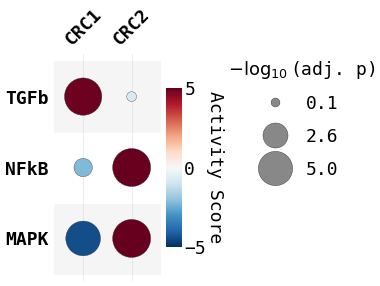

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns

# ── Selection ──────────────────────────────────────────────
MODULES  = ['CRC1', 'CRC2']
PATHWAYS = ['TGFb', 'NFkB', 'MAPK']
CLIP     = 5
# ──────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.family':    'monospace',
    'font.monospace': ['Courier New', 'DejaVu Sans Mono'],
    'font.size':       16,
})

df = pw_joint[
    pw_joint['Pathway'].isin(PATHWAYS) &
    pw_joint['Module'].isin(MODULES)
].copy()

df['Activity_clipped'] = df['Activity'].clip(-CLIP, CLIP)
df['neg_log10_padj']   = -np.log10(df['padj'].clip(lower=1e-5))

pathway_order = PATHWAYS[::-1]
module_order  = MODULES
df['x'] = df['Module'].map({m: i for i, m in enumerate(module_order)})
df['y'] = df['Pathway'].map({p: i for i, p in enumerate(pathway_order)})

# ── Size scaling ───────────────────────────────────────────
MAX_SIZE, MIN_SIZE = 3000, 200
sig_min, sig_max = df['neg_log10_padj'].min(), df['neg_log10_padj'].max()
size_range = sig_max - sig_min or 1
dot_sizes = MIN_SIZE + (df['neg_log10_padj'] - sig_min) / size_range * (MAX_SIZE - MIN_SIZE)

# ── Figure ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for i in range(len(pathway_order)):
    ax.axhspan(i - 0.5, i + 0.5,
               color='#f5f5f5' if i % 2 == 0 else 'white', zorder=0)
for xi in range(len(module_order)):
    ax.axvline(xi, color='#dddddd', linewidth=0.8, zorder=1)

norm = mcolors.TwoSlopeNorm(vmin=-CLIP, vcenter=0, vmax=CLIP)
xx = ax.scatter(
    df['x'], df['y'],
    c=df['Activity_clipped'], s=dot_sizes,
    cmap='RdBu_r', norm=norm,
    edgecolors='#333333', linewidths=0.5,
    zorder=3,
)

ax.set_xticks(range(len(module_order)))
ax.set_yticks(range(len(pathway_order)))
ax.set_xticklabels(module_order, size=26, fontweight='bold', rotation=45, ha='center', va='bottom')
ax.set_yticklabels(pathway_order, size=26, fontweight='bold', rotation=0)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlim(-0.6, len(module_order) - 0.4)
ax.set_ylim(-0.6, len(pathway_order) - 0.4)
ax.tick_params(length=0, pad=8)
sns.despine(ax=ax, left=True, bottom=True, top=True, right=True)

# ── Colorbar — bigger, more readable ──────────────────────
cbar = fig.colorbar(
    xx, ax=ax,
    shrink=0.7,       # taller bar (was 0.4)
    pad=0.04,
    aspect=10,         # chunkier/wider bar (was 10)
    ticks=[-CLIP, 0, CLIP]
)
cbar.set_label('Activity Score', labelpad=0, rotation=270,
               va='bottom', fontsize=26)
cbar.ax.tick_params(labelsize=26, length=0)
cbar.outline.set_visible(False)

# ── Size legend — spread out, no overlap ──────────────────
# Use only 3 ticks and space them at 0%, 50%, 100% of the range
sig_ticks  = np.array([sig_min,
                        sig_min + 0.5 * size_range,
                        sig_max])
size_ticks = MIN_SIZE + (sig_ticks - sig_min) / size_range * (MAX_SIZE - MIN_SIZE)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#888888', markeredgecolor='#333333',
           markeredgewidth=0.6,
           markersize=np.sqrt(s) * 0.9,  # slightly bigger markers
           label=f'{v:.1f}')
    for s, v in zip(size_ticks, sig_ticks)
]
ax.legend(
    handles=legend_handles,
    title='$-\\log_{10}$(adj. p)',
    title_fontsize=26,        # was 14
    fontsize=26,              # was 14
    bbox_to_anchor=(1.55, 1.02),
    loc='upper left',
    frameon=False,
    labelspacing=0.8,         # was 1.2 — more vertical breathing room
    handletextpad=1.2,
)

plt.tight_layout()
plt.savefig("heatmap_dotplot.svg", bbox_inches="tight", dpi=300)
plt.savefig("heatmap_dotplot.pdf", bbox_inches="tight", dpi=300)
plt.show()

### Pathway targets

In [92]:
import scanpy as sc
sc.pp.log1p(adata_crc)
sc.tl.rank_genes_groups(adata_crc, groupby="top_module")

In [93]:
deg_1 = sc.get.rank_genes_groups_df(adata_crc, group="1").set_index("names")

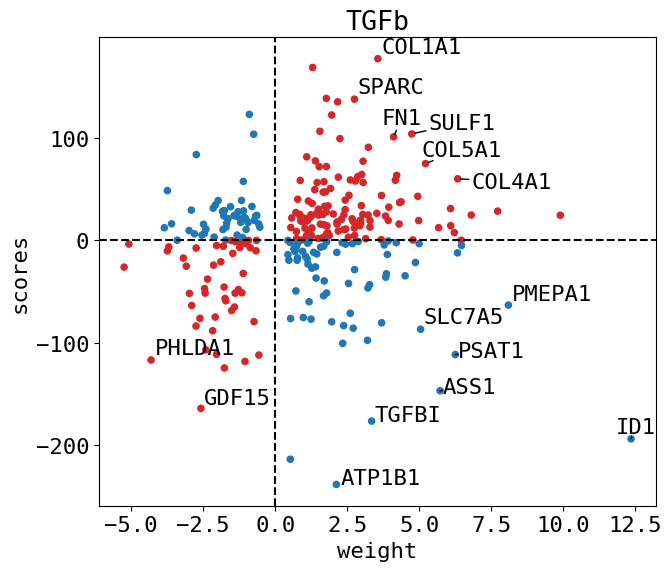

In [94]:
dc.pl.source_targets(data=deg_1, x="weight", y="scores", net=pw_progeny, name="TGFb", top=15, figsize=(7, 6))

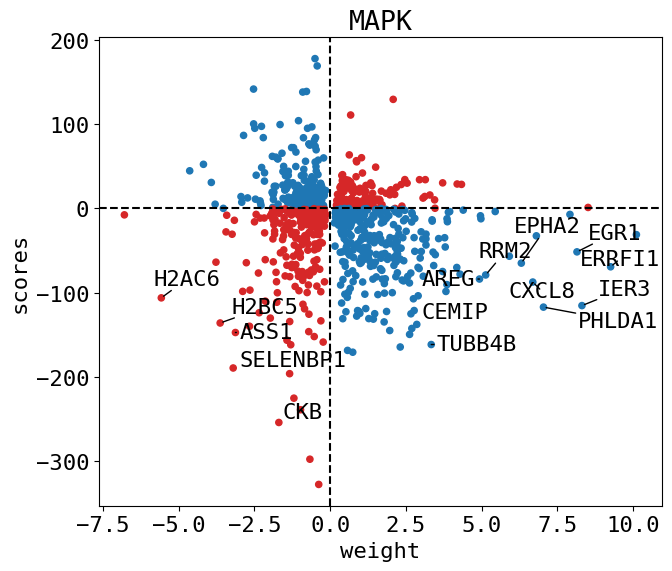

In [95]:
dc.pl.source_targets(data=deg_1, x="weight", y="scores", net=pw_progeny, name="MAPK", top=15, figsize=(7, 6))

In [96]:
deg_2 = sc.get.rank_genes_groups_df(adata_crc, group="2").set_index("names")

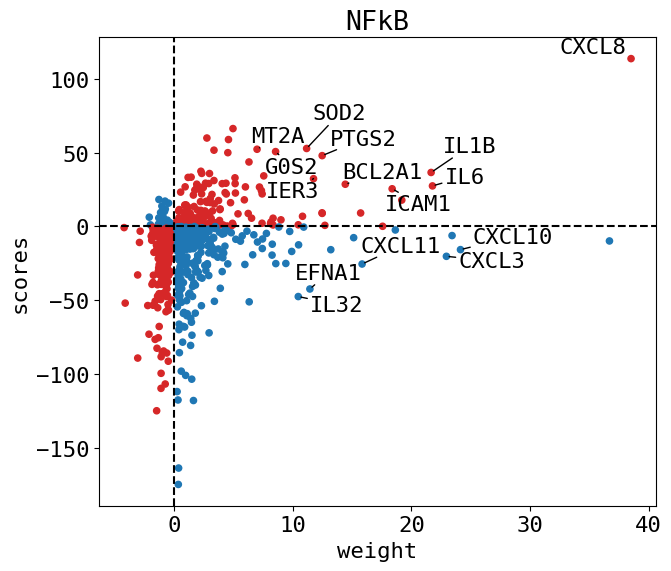

In [97]:
dc.pl.source_targets(data=deg_2, x="weight", y="scores", net=pw_progeny, name="NFkB", top=15, figsize=(7, 6))

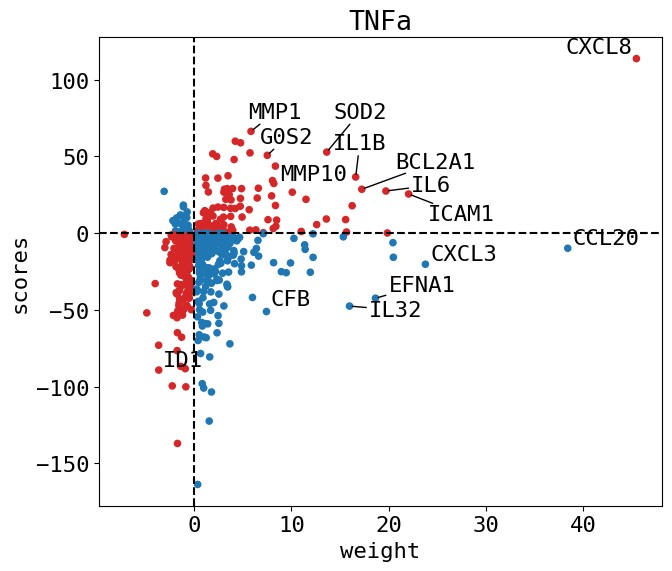

In [98]:
dc.pl.source_targets(data=deg_2, x="weight", y="scores", net=pw_progeny, name="TNFa", top=15, figsize=(7, 6))

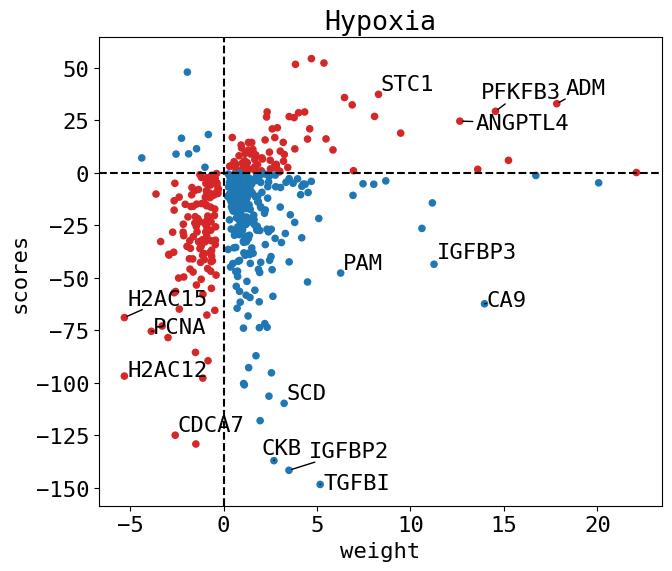

In [99]:
dc.pl.source_targets(data=deg_2, x="weight", y="scores", net=pw_progeny, name="Hypoxia", top=15, figsize=(7, 6))

# Pathway-based perturbations

In [254]:
is_celltype1 = "Fibroblast"   # CRC1 perturbation
is_celltype2 = "Myeloid"      # CRC2 perturbation

def compute_microenv_logfc(adata, domains_key, labels_key, ref_label, crc_label):
    """Compute global and cell-type-specific logFC between a CRC microenvironment and reference."""
    adata.X = adata.layers['counts']
    pdata_global = dc.pp.pseudobulk(
        adata=adata, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_global, target_sum=1e4)
    sc.pp.log1p(pdata_global)

    global_logfc_series = pd.Series(
        (pdata_global[pdata_global.obs[domains_key] == crc_label].X
         - pdata_global[pdata_global.obs[domains_key] == ref_label].X).flatten(),
        index=pdata_global.var_names,
    )

    pdata_ct = dc.pp.pseudobulk(
        adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_ct, target_sum=1e4)
    sc.pp.log1p(pdata_ct)

    cell_types_with_both = [
        ct for ct in pdata_ct.obs[labels_key].unique()
        if ((pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)).any()
        and ((pdata_ct.obs[domains_key] == crc_label) & (pdata_ct.obs[labels_key] == ct)).any()
    ]

    domain_logfc_df = pd.concat(
        [
            pd.Series(
                (pdata_ct[(pdata_ct.obs[domains_key] == crc_label) & (pdata_ct.obs[labels_key] == ct)].X
                 - pdata_ct[(pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)].X
                ).flatten(),
                index=pdata_ct.var_names,
                name=ct,
            )
            for ct in cell_types_with_both
        ],
        axis=1,
    ).T

    print(f"Global logFC: {global_logfc_series.shape[0]} genes")
    print(f"Cell-type logFC: {domain_logfc_df.shape[0]} cell types x {domain_logfc_df.shape[1]} genes")
    return global_logfc_series, domain_logfc_df

In [255]:
adata_pert     = results[is_celltype1].copy()
adata_ct2_pert = results[is_celltype2].copy()

In [256]:
for _ap in [adata_pert, adata_ct2_pert]:
    _ap.obs['domain'] = _ap.obs['microenvironment']
    _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})
    _ap.obs['domain'] = _ap.obs['domain'].astype('category')

/tmp/ipykernel_4006449/1005614181.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})
/tmp/ipykernel_4006449/1005614181.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})


In [257]:
print(f"{is_celltype1} domains:"); display(adata_pert.obs.domain.value_counts())
print(f"{is_celltype2} domains:"); display(adata_ct2_pert.obs.domain.value_counts())

Fibroblast domains:


domain
CRC1       28955
CRC4        6272
210_TVA     4550
CRC3        3566
CRC2        2736
Control     2456
Name: count, dtype: int64

Myeloid domains:


domain
CRC2       13192
CRC1        7939
210_TVA     7904
CRC3        5221
CRC4        3146
Control     1514
Name: count, dtype: int64

In [258]:
for _ap in [adata_pert, adata_ct2_pert]:
    _ap.X = _ap.layers['counts'].copy()
    sc.pp.normalize_total(_ap, target_sum=1e4)
    sc.pp.log1p(_ap)

1. Cell-type-specific DE analysis

In [259]:
adata.obs['microenvironment'].replace({'210_REF': 'Control'}, inplace=True)

adata_sub = adata[adata.obs['microenvironment'].isin(['Control', 'CRC1', 'CRC2'])].copy()

# Pseudobulk logFC for ALL cell types (used for perturbation vectors)
global_logfc_crc1, ct_logfc_df_crc1 = compute_microenv_logfc(
    adata_sub, domains_key='microenvironment', labels_key=labels_key,
    ref_label='Control', crc_label='CRC1'
)
global_logfc_crc2, ct_logfc_df_crc2 = compute_microenv_logfc(
    adata_sub, domains_key='microenvironment', labels_key=labels_key,
    ref_label='Control', crc_label='CRC2'
)

# Cell-type-specific Wilcoxon DE: CT1 CRC1 vs Control
adata_ct1_sub = adata_sub[adata_sub.obs[labels_key] == is_celltype1].copy()
adata_ct1_sub.X = adata_ct1_sub.layers['counts'].copy()
sc.pp.normalize_total(adata_ct1_sub, target_sum=1e4)
sc.pp.log1p(adata_ct1_sub)
sc.tl.rank_genes_groups(adata_ct1_sub, groupby='microenvironment',
                        groups=['CRC1'], reference='Control', method='wilcoxon')
deg_ct1_crc1 = sc.get.rank_genes_groups_df(adata_ct1_sub, group='CRC1')

# Cell-type-specific Wilcoxon DE: CT2 CRC2 vs Control
adata_ct2_sub = adata_sub[adata_sub.obs[labels_key] == is_celltype2].copy()
adata_ct2_sub.X = adata_ct2_sub.layers['counts'].copy()
sc.pp.normalize_total(adata_ct2_sub, target_sum=1e4)
sc.pp.log1p(adata_ct2_sub)
sc.tl.rank_genes_groups(adata_ct2_sub, groupby='microenvironment',
                        groups=['CRC2'], reference='Control', method='wilcoxon')
deg_ct2_crc2 = sc.get.rank_genes_groups_df(adata_ct2_sub, group='CRC2')

/tmp/ipykernel_4006449/1732564684.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs['microenvironment'].replace({'210_REF': 'Control'}, inplace=True)


Global logFC: 2000 genes
Cell-type logFC: 9 cell types x 2000 genes
Global logFC: 2000 genes
Cell-type logFC: 9 cell types x 2000 genes


In [260]:
deg_ct1_crc1

,names,scores,logfoldchanges,pvals,pvals_adj
0,COL1A1,45.708591,4.127557,0.000000e+00,0.000000e+00
1,COL1A2,39.792480,4.230020,0.000000e+00,0.000000e+00
2,SPARC,39.247776,4.419678,0.000000e+00,0.000000e+00
3,COL3A1,34.953167,3.267604,1.159111e-267,5.795554e-265
4,MMP2,33.023300,3.652195,3.761138e-239,1.504455e-236
...,...,...,...,...,...
1995,SCARA5,-3.531029,-2.320505,4.139457e-04,3.712517e-03
1996,ADAM28,-5.678895,-2.692927,1.355682e-08,2.101832e-07
1997,JCHAIN,-7.422693,-2.852822,1.147627e-13,2.441759e-12
1998,IGKC,-8.458501,-1.489881,2.708371e-17,6.687335e-16


In [261]:
deg_ct2_crc2

,names,scores,logfoldchanges,pvals,pvals_adj
0,CXCL8,42.851814,8.651569,0.000000e+00,0.000000e+00
1,SOD2,22.917721,4.344518,3.093500e-116,2.062334e-113
2,MMP1,16.896313,5.374287,4.789370e-64,1.368391e-61
3,MMP3,16.009375,6.047008,1.099097e-57,2.747742e-55
4,NAMPT,15.896811,4.470918,6.667285e-57,1.481619e-54
...,...,...,...,...,...
1995,HLA-DPA1,-11.277074,-3.335763,1.703178e-29,2.270904e-27
1996,C1QC,-17.120207,-4.515883,1.049009e-65,3.496698e-63
1997,CD74,-19.070591,-3.229342,4.432633e-81,1.773053e-78
1998,HLA-DRA,-22.289396,-3.868856,4.682561e-110,2.341280e-107


2. Find pathway-defining genes

In [262]:
logfc_threshold  = 0.5
padj_threshold   = 0.05
weight_threshold = 1


In [263]:
pw_tgfb = pw_progeny[(pw_progeny.source == 'TGFb') & (pw_progeny.weight.abs() > weight_threshold)]
pw_mapk = pw_progeny[(pw_progeny.source == 'MAPK') & (pw_progeny.weight.abs() > weight_threshold)]
pw_nfkb = pw_progeny[(pw_progeny.source == 'NFkB') & (pw_progeny.weight.abs() > weight_threshold)]

print(f"TGFb targets: {len(pw_tgfb)}, MAPK targets: {len(pw_mapk)}, NFkB targets: {len(pw_nfkb)}")

TGFb targets: 1151, MAPK targets: 3240, NFkB targets: 2663


3. Directional intersection: DE genes ∩ pathway targets

In [264]:
filter_by_pathway = True   # False → skip pathway intersection, use all |logFC|>threshold DE genes

def _pw_concordant(deg_df, pw_df):
    """Genes where DE logFC sign matches pathway weight sign (concordant direction)."""
    pw_weights = pw_df.set_index('target')['weight']
    merged = deg_df[deg_df['pvals_adj'] < padj_threshold].set_index('names').join(pw_weights, how='inner')
    mask = (
        ((merged['logfoldchanges'] >  logfc_threshold) & (merged['weight'] >  weight_threshold)) |
        ((merged['logfoldchanges'] < -logfc_threshold) & (merged['weight'] < -weight_threshold))
    )
    return set(merged.index[mask])

def _all_de(deg_df):
    """All DE genes passing |logFC| and padj thresholds."""
    return set(
        deg_df[(deg_df['pvals_adj'] < padj_threshold) &
               (deg_df['logfoldchanges'].abs() > logfc_threshold)]['names']
    )

if filter_by_pathway:
    genes_crc1_cf = _pw_concordant(deg_ct1_crc1, pw_tgfb) | _pw_concordant(deg_ct1_crc1, pw_mapk)
    genes_crc2_cf = _pw_concordant(deg_ct2_crc2, pw_nfkb) | _pw_concordant(deg_ct2_crc2, pw_mapk)
    print(f"CRC1 CF genes (TGFb+MAPK concordant): {len(genes_crc1_cf)}")
    print(f"CRC2 CF genes (NFkB+MAPK concordant): {len(genes_crc2_cf)}")
else:
    genes_crc1_cf = _all_de(deg_ct1_crc1)
    genes_crc2_cf = _all_de(deg_ct2_crc2)
    print(f"CRC1 CF genes (all DE): {len(genes_crc1_cf)}")
    print(f"CRC2 CF genes (all DE): {len(genes_crc2_cf)}")

CRC1 CF genes (TGFb+MAPK concordant): 92
CRC2 CF genes (NFkB+MAPK concordant): 61


In [265]:
assert len(genes_crc1_cf) > 0, "CRC1 CF gene set is empty"
assert len(genes_crc2_cf) > 0, "CRC2 CF gene set is empty"

In [266]:
deg_ct2_crc2

,names,scores,logfoldchanges,pvals,pvals_adj
0,CXCL8,42.851814,8.651569,0.000000e+00,0.000000e+00
1,SOD2,22.917721,4.344518,3.093500e-116,2.062334e-113
2,MMP1,16.896313,5.374287,4.789370e-64,1.368391e-61
3,MMP3,16.009375,6.047008,1.099097e-57,2.747742e-55
4,NAMPT,15.896811,4.470918,6.667285e-57,1.481619e-54
...,...,...,...,...,...
1995,HLA-DPA1,-11.277074,-3.335763,1.703178e-29,2.270904e-27
1996,C1QC,-17.120207,-4.515883,1.049009e-65,3.496698e-63
1997,CD74,-19.070591,-3.229342,4.432633e-81,1.773053e-78
1998,HLA-DRA,-22.289396,-3.868856,4.682561e-110,2.341280e-107


4. Generate counterfactual populations for each target gene set

In [267]:
# logFC vectors for ALL cell types, restricted to CRC1 CF gene set
logfc_sub_crc1 = {ct: ct_logfc_df_crc1.loc[ct].reindex(list(genes_crc1_cf)).fillna(0)
                  for ct in ct_logfc_df_crc1.index}
print(f"logfc_sub_crc1: {len(logfc_sub_crc1)} cell types, {len(genes_crc1_cf)} genes each")

logfc_sub_crc1: 9 cell types, 92 genes each


In [268]:
from cellina._spatial_utils import make_neighbor_perturbation

adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

make_neighbor_perturbation(
    adata,
    perturbations=logfc_sub_crc1,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

In [269]:
adata.X = adata.layers['counts'].copy()

In [270]:
is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)

# Control cells for each perturbation
idx_ct1_ctrl = np.where(~is_tumor_region & (adata.obs[labels_key] == is_celltype1))[0]
idx_ct2_ctrl = np.where(~is_tumor_region & (adata.obs[labels_key] == is_celltype2))[0]

print(f"Control {is_celltype1}: {len(idx_ct1_ctrl)}")
print(f"Control {is_celltype2}: {len(idx_ct2_ctrl)}")

Control Fibroblast: 7006
Control Myeloid: 9418


In [271]:
adata_pert.uns['pert_crc1'] = model.get_perturbed_expression(
    adata,
    indices=idx_ct1_ctrl,
    batch_size=4096,
    spatial_obsm_key="spatial_x_cf",
    library_size=1e4)

In [272]:
# logFC vectors for ALL cell types, restricted to CRC2 CF gene set
logfc_sub_crc2 = {ct: ct_logfc_df_crc2.loc[ct].reindex(list(genes_crc2_cf)).fillna(0)
                  for ct in ct_logfc_df_crc2.index}
print(f"logfc_sub_crc2: {len(logfc_sub_crc2)} cell types, {len(genes_crc2_cf)} genes each")

logfc_sub_crc2: 9 cell types, 61 genes each


In [273]:
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

make_neighbor_perturbation(
    adata,
    perturbations=logfc_sub_crc2,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

In [274]:
adata.X = adata.layers['counts'].copy()

adata_ct2_pert.uns['pert_crc2'] = model.get_perturbed_expression(
    adata,
    indices=idx_ct2_ctrl,
    batch_size=4096,
    spatial_obsm_key="spatial_x_cf",
    library_size=1e4)

5. Validate: correlation with observed CRC microenvironments

In [275]:
# CT1 control expression (actual counts, normalized)
adata_pert.X = adata_pert.layers['counts'].copy()
sc.pp.normalize_total(adata_pert, target_sum=1e4)
sc.pp.log1p(adata_pert)

mask_ctrl_ct1 = ~adata_pert.obs['domain'].str.contains('CRC')
control_ct1 = np.asarray(adata_pert.X.todense()[mask_ctrl_ct1])

In [276]:
# CRC1 target expression
mask_crc1 = adata_pert.obs['domain'].str.contains('CRC1')
target_ct1 = np.asarray(adata_pert.X.todense()[mask_crc1])

cf1 = np.log1p(adata_pert.uns['pert_crc1'])

In [277]:
pear_cf1, spear_cf1 = compute_correlations(control_ct1, target_ct1, cf1, deg=deg)
print(f"CF1 ({is_celltype1}, CRC1 TGFb+MAPK)  — Pearson: {pear_cf1:.3f}, Spearman: {spear_cf1:.3f}")

CF1 (Fibroblast, CRC1 TGFb+MAPK)  — Pearson: 0.451, Spearman: 0.515


In [278]:
# CT2 control and CRC2 target expression
adata_ct2_pert.X = adata_ct2_pert.layers['counts'].copy()
sc.pp.normalize_total(adata_ct2_pert, target_sum=1e4)
sc.pp.log1p(adata_ct2_pert)

mask_ctrl_ct2 = ~adata_ct2_pert.obs['domain'].str.contains('CRC')
mask_crc2     =  adata_ct2_pert.obs['domain'].str.contains('CRC2')

control_ct2 = np.asarray(adata_ct2_pert.X.todense()[mask_ctrl_ct2])
target_ct2  = np.asarray(adata_ct2_pert.X.todense()[mask_crc2])

cf2 = np.log1p(adata_ct2_pert.uns['pert_crc2'])

In [279]:
pear_cf2, spear_cf2 = compute_correlations(control_ct2, target_ct2, cf2, deg=deg)
print(f"CF2 ({is_celltype2}, CRC2 NFkB+MAPK) — Pearson: {pear_cf2:.3f}, Spearman: {spear_cf2:.3f}")

CF2 (Myeloid, CRC2 NFkB+MAPK) — Pearson: 0.789, Spearman: 0.771


In [280]:
pert_results = {
    f'{is_celltype1} CF (CRC1)': {'pearson': pear_cf1, 'spearman': spear_cf1},
    f'{is_celltype2} CF (CRC2)': {'pearson': pear_cf2, 'spearman': spear_cf2},
}

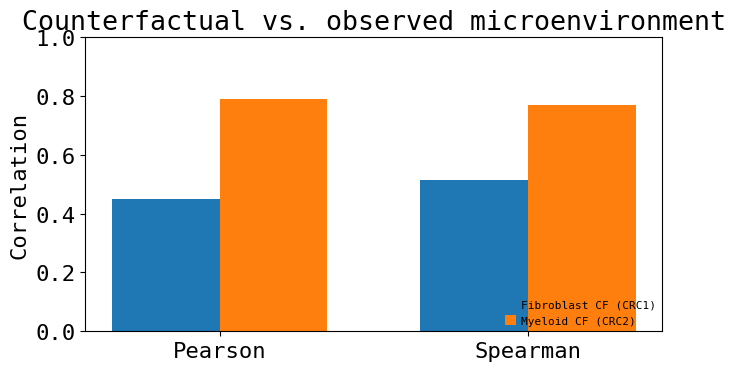

In [282]:
fig, ax = plt.subplots(figsize=(7, 4))
populations = list(pert_results.keys())
x = np.arange(2)
width = 0.35

for i, (pop, vals) in enumerate(pert_results.items()):
    ax.bar(x + i * width, [vals['pearson'], vals['spearman']], width, label=pop)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(['Pearson', 'Spearman'])
ax.set_ylim(0, 1)
ax.set_ylabel("Correlation")
ax.set_title("Counterfactual vs. observed microenvironment")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [283]:
def cf_logfc(cf_expr, ctrl_expr):
    """log2(mean CF / mean control + 1) per gene, 1e4-normalised."""
    ctrl_n = ctrl_expr / (ctrl_expr.sum(1, keepdims=True) + 1e-9) * 1e4
    cf_n   = cf_expr   / (cf_expr.sum(1,  keepdims=True) + 1e-9) * 1e4
    return np.log2(cf_n.mean(0) + 1) - np.log2(ctrl_n.mean(0) + 1)

lfc_cf1 = cf_logfc(adata_pert.uns['pert_crc1'],     adata.obsm['recon_x'][idx_ct1_ctrl])
lfc_cf2 = cf_logfc(adata_ct2_pert.uns['pert_crc2'], adata.obsm['recon_x'][idx_ct2_ctrl])

print(f"Genes strongly responding in CF1 (|logFC|>0.5): {(np.abs(lfc_cf1)>0.5).sum()}")
print(f"Genes strongly responding in CF2 (|logFC|>0.5): {(np.abs(lfc_cf2)>0.5).sum()}")

Genes strongly responding in CF1 (|logFC|>0.5): 18
Genes strongly responding in CF2 (|logFC|>0.5): 64


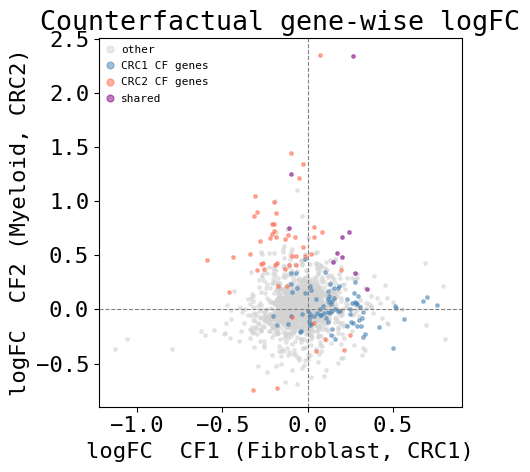

In [284]:
gene_names = np.array(adata.var_names)
in_crc1 = np.isin(gene_names, list(genes_crc1_cf))
in_crc2 = np.isin(gene_names, list(genes_crc2_cf))
in_both = in_crc1 & in_crc2

fig, ax = plt.subplots(figsize=(5, 5))
for mask, col, lbl, z in [
    (~in_crc1 & ~in_crc2, 'lightgrey', 'other', 0),
    (in_crc1 & ~in_crc2,  'steelblue', 'CRC1 CF genes', 1),
    (~in_crc1 & in_crc2,  'tomato',    'CRC2 CF genes', 1),
    (in_both,              'purple',    'shared', 2),
]:
    ax.scatter(lfc_cf1[mask], lfc_cf2[mask], c=col, s=6, alpha=0.5, label=lbl, zorder=z)

ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f"logFC  CF1 ({is_celltype1}, CRC1)")
ax.set_ylabel(f"logFC  CF2 ({is_celltype2}, CRC2)")
ax.set_title("Counterfactual gene-wise logFC")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

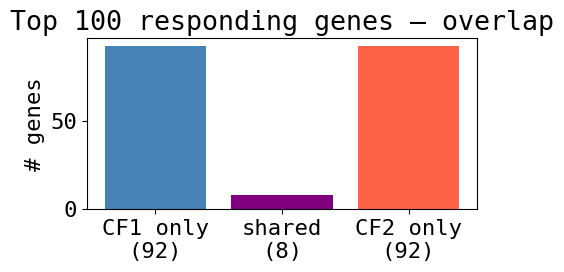

In [285]:
top_k = 100
top_cf1_genes = set(gene_names[np.argsort(-np.abs(lfc_cf1))[:top_k]])
top_cf2_genes = set(gene_names[np.argsort(-np.abs(lfc_cf2))[:top_k]])

try:
    from matplotlib_venn import venn2
    fig, ax = plt.subplots(figsize=(5, 4))
    venn2([top_cf1_genes, top_cf2_genes],
          set_labels=(f'CF1 top {top_k}\n({is_celltype1}, CRC1)',
                      f'CF2 top {top_k}\n({is_celltype2}, CRC2)'), ax=ax)
    ax.set_title(f'Top {top_k} responding genes')
    plt.tight_layout()
    plt.show()
except ImportError:
    shared = top_cf1_genes & top_cf2_genes
    fig, ax = plt.subplots(figsize=(5, 3))
    counts = [len(top_cf1_genes - top_cf2_genes), len(shared), len(top_cf2_genes - top_cf1_genes)]
    labels = [f'CF1 only\n({counts[0]})', f'shared\n({counts[1]})', f'CF2 only\n({counts[2]})']
    ax.bar(labels, counts, color=['steelblue', 'purple', 'tomato'])
    ax.set_ylabel('# genes')
    ax.set_title(f'Top {top_k} responding genes — overlap')
    plt.tight_layout()
    plt.show()